In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler

In [7]:
# Load the dataset
df = pd.read_csv('titanic.csv')

In [9]:
# Display the first few rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# Cleaning the Data

In [16]:

df.shape

(418, 11)

In [18]:
# Check for missing values in the dataset
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64

### 327 Nulls in cabin colum, then we drop the coulumn since there won't be any point to mean impute

In [14]:
# 
df = df.drop(columns='Cabin')

In [15]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [17]:
# Mean imputing the missing values in the 'Age' column
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\Phalanndwa Munyai\AppData\Local\Temp\ipykernel_17992\2810759747.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [20]:
# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

In [25]:
# Encode categorical variables using one-hot encoding
df[encoder.get_feature_names_out(['Sex'])] = encoder.fit_transform(df[['Sex']])
df.drop(columns='Sex', axis=1)


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Embarked,Sex_female,Sex_male
0,892,0,3,"Kelly, Mr. James",34.50000,0,0,330911,7.8292,Q,0.0,1.0
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",47.00000,1,0,363272,7.0000,S,1.0,0.0
2,894,0,2,"Myles, Mr. Thomas Francis",62.00000,0,0,240276,9.6875,Q,0.0,1.0
3,895,0,3,"Wirz, Mr. Albert",27.00000,0,0,315154,8.6625,S,0.0,1.0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.00000,1,1,3101298,12.2875,S,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",30.27259,0,0,A.5. 3236,8.0500,S,0.0,1.0
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",39.00000,0,0,PC 17758,108.9000,C,1.0,0.0
415,1307,0,3,"Saether, Mr. Simon Sivertsen",38.50000,0,0,SOTON/O.Q. 3101262,7.2500,S,0.0,1.0
416,1308,0,3,"Ware, Mr. Frederick",30.27259,0,0,359309,8.0500,S,0.0,1.0


In [ ]:
#Using get_dummies to encode categorical variables
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True

In [35]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_Q,Embarked_S
0,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,0.0,1.0,True,False
1,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,1.0,0.0,False,True
2,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,0.0,1.0,True,False
3,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,0.0,1.0,False,True
4,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,1.0,0.0,False,True


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    418 non-null    int64  
 1   Pclass      418 non-null    int64  
 2   Name        418 non-null    object 
 3   Sex         418 non-null    object 
 4   Age         418 non-null    float64
 5   SibSp       418 non-null    int64  
 6   Parch       418 non-null    int64  
 7   Ticket      418 non-null    object 
 8   Fare        417 non-null    float64
 9   Sex_female  418 non-null    float64
 10  Sex_male    418 non-null    float64
 11  Embarked_Q  418 non-null    bool   
 12  Embarked_S  418 non-null    bool   
dtypes: bool(2), float64(4), int64(4), object(3)
memory usage: 36.9+ KB


In [33]:
# Dropping passenger ID
df.drop(columns='PassengerId', axis=1, inplace=True)

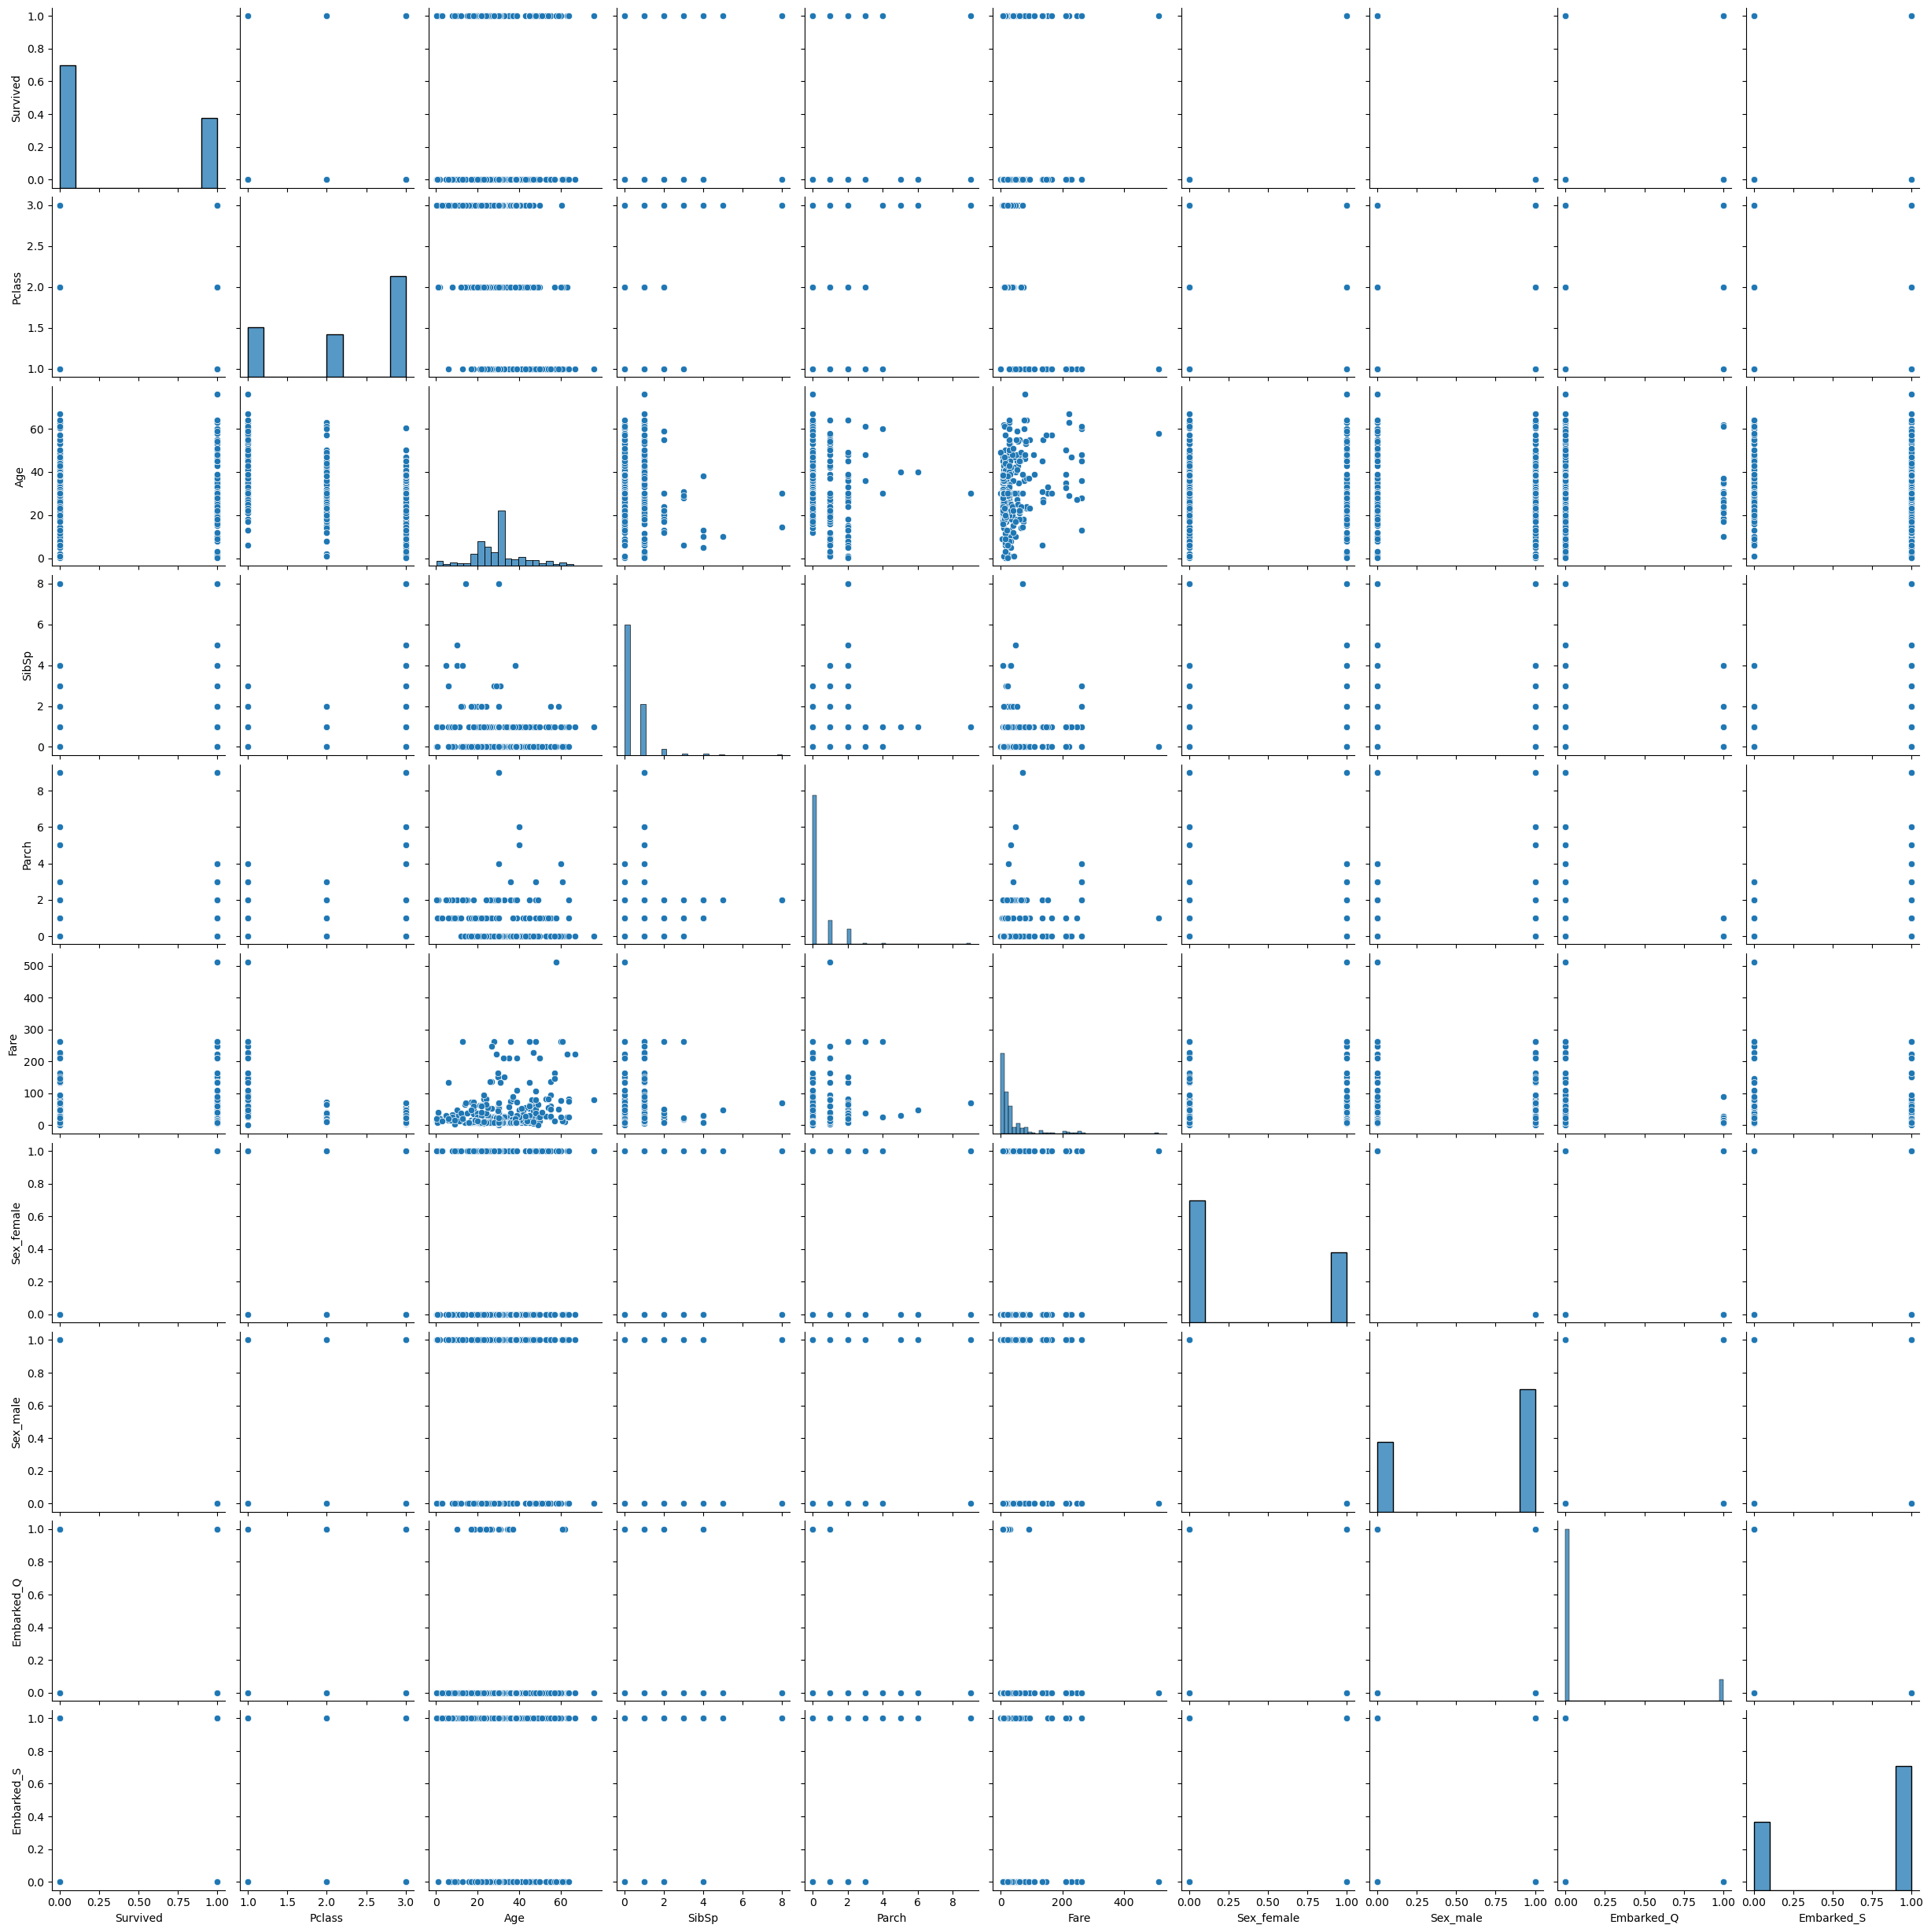

In [40]:
# Doing a pairplot to visualize the relationships between features and the target variable
sns.pairplot(df)

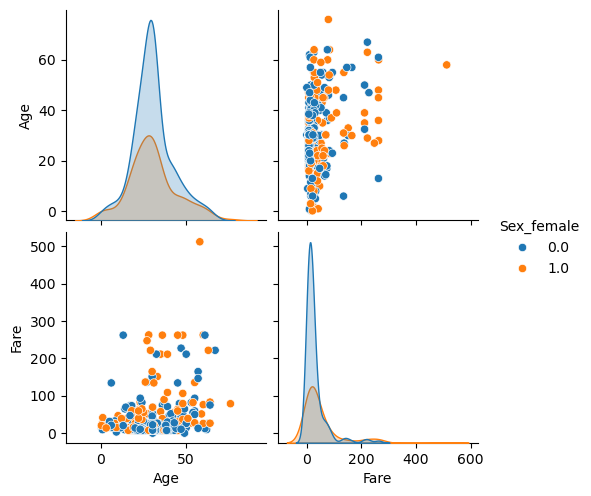

In [43]:
# Visualizing the relationships between Age and Fare
sns.pairplot(df, vars=['Age', 'Fare'], hue='Sex_female')

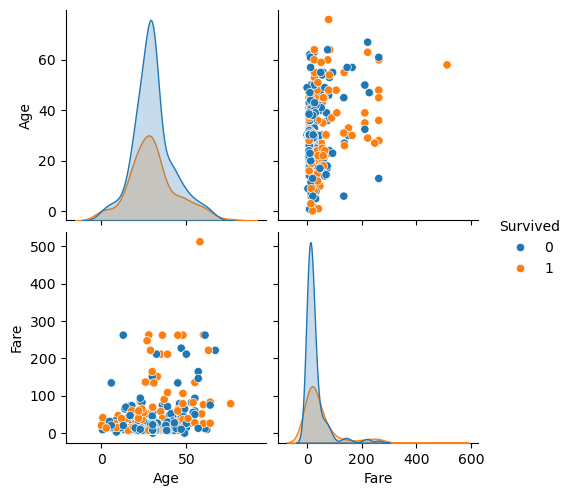

In [45]:
sns.pairplot(df, vars=['Age', 'Fare'], hue='Survived')

<Axes: xlabel='Pclass', ylabel='count'>

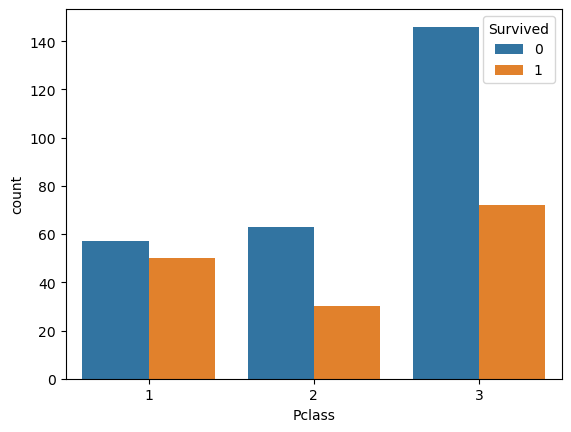

In [46]:
sns.countplot(data=df, x='Pclass', hue='Survived')

<Axes: xlabel='Sex_female', ylabel='count'>

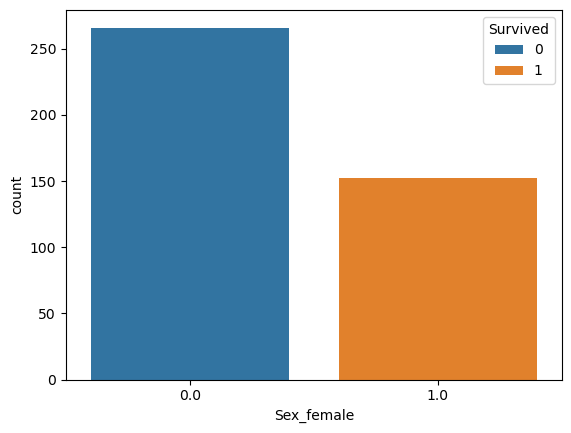

In [47]:
sns.countplot(data=df, x='Sex_female', hue='Survived')

C:\Users\Phalanndwa Munyai\AppData\Local\Temp\ipykernel_17992\418659566.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Male', 'Female'])


[Text(0, 0, 'Male'), Text(1, 0, 'Female')]

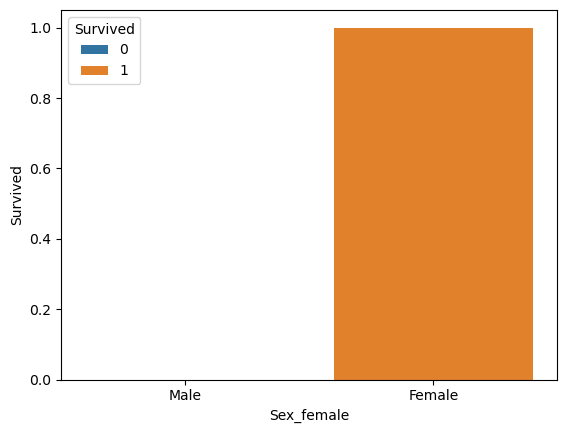

In [50]:
ax = sns.barplot(data=df, x='Sex_female', y='Survived', hue='Survived')
ax.set_xticklabels(['Male', 'Female'])

<Axes: xlabel='Pclass', ylabel='Survived'>

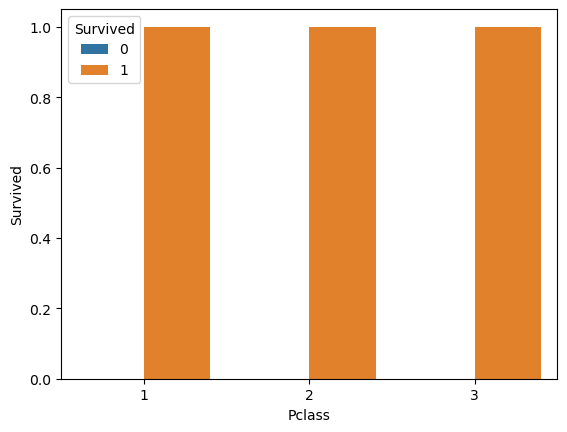

In [53]:
sns.barplot(data=df, x='Pclass', y='Survived', hue='Survived')

In [54]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [55]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_Q,Embarked_S,FamilySize
0,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,0.0,1.0,True,False,1
1,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,1.0,0.0,False,True,2
2,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,0.0,1.0,True,False,1
3,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,0.0,1.0,False,True,1
4,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,1.0,0.0,False,True,3


<Axes: xlabel='FamilySize', ylabel='Survived'>

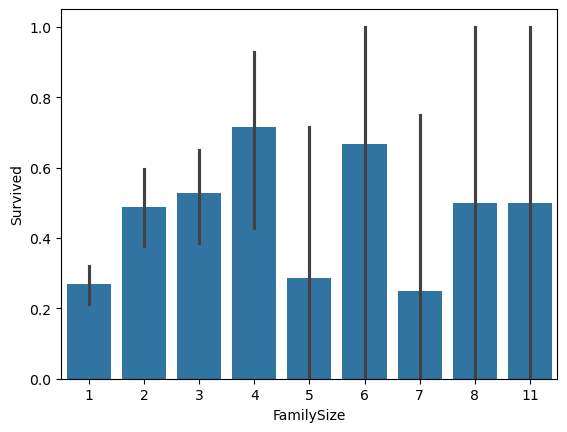

In [56]:
sns.barplot(data=df, x='FamilySize', y='Survived')

In [58]:
pd.crosstab(df['Sex_female'], df['Survived'])

Survived,0,1
Sex_female,,
0.0,266,0
1.0,0,152
